<a href="https://colab.research.google.com/github/16ajoop/Machine-Learning/blob/main/LNNwith_2_dense_layer(no_activation_fn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
TRAIN_DIR ="/content/drive/MyDrive/cats-dogs-classification/train"
TEST_DIR = "/content/drive/MyDrive/cats-dogs-classification/test"

In [4]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import math

In [5]:
# CONFIG
IMG_HEIGHT, IMG_WIDTH = 150, 150
IMG_CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 20

In [6]:
# LOAD data
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.1, subset="training",
    seed=123, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.1, subset="validation",
    seed=123, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, shuffle=False
)

CLASS_NAMES = train_ds.class_names
print("Classes:", CLASS_NAMES)

Found 1120 files belonging to 2 classes.
Using 1008 files for training.
Found 1120 files belonging to 2 classes.
Using 112 files for validation.
Found 280 files belonging to 2 classes.
Classes: ['cats', 'dogs']


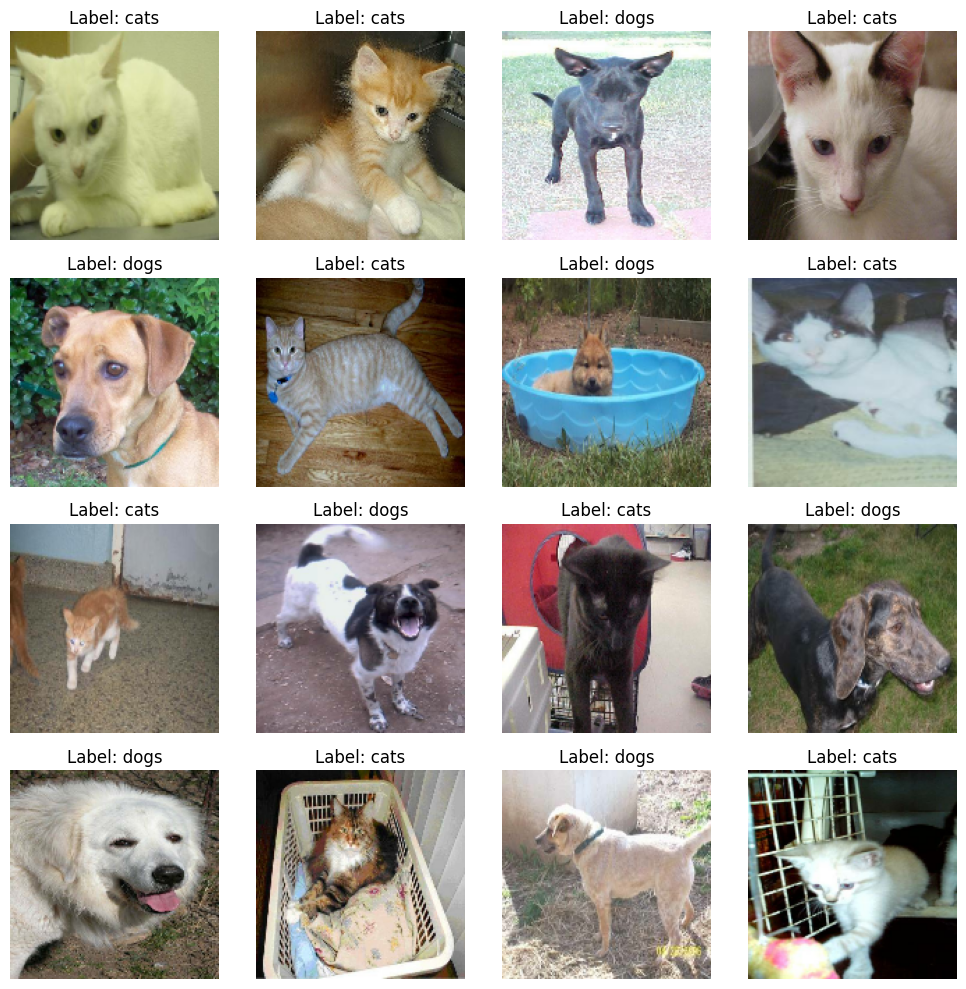

In [7]:
# peek att the batch of images before caching/prefetch changes anything
for image_batch, label_batch in train_ds.take(1):
  fig, axes = plt.subplots(4, 4, figsize=(10, 10))
  for i in range(16):
    ax = axes[i // 4, i % 4]
    ax.imshow(image_batch[i].numpy().astype("uint8"))
    ax.set_title(f"Label: {CLASS_NAMES[label_batch[i]]}")
    ax.axis("off")
  plt.tight_layout()
  plt.show()

In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [17]:
# MODEL:  FLATTEN ---> DENSE(128, no activation) ---> DENSE(output)
linear_model = keras.Sequential([
    keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    keras.layers.Rescaling(1./255),
    keras.layers.Flatten(),
    keras.layers.Dense(128),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

In [18]:
linear_model.compile(
    optimizer = "adam",
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ["accuracy"]
)

linear_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     8,640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,640,386 (32.96 MB)

 Trainable params: 8,640,386 (32.96 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
#  TRAIN
history = linear_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4831 - loss: 86.2450 - val_accuracy: 0.6161 - val_loss: 10.4413
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5655 - loss: 6.8632 - val_accuracy: 0.6161 - val_loss: 9.7976
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5020 - loss: 15.6627 - val_accuracy: 0.6250 - val_loss: 12.6437
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6032 - loss: 4.9061 - val_accuracy: 0.4286 - val_loss: 9.2743
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6062 - loss: 4.7487 - val_accuracy: 0.6250 - val_loss: 8.3069
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5446 - loss: 8.4434 - val_accuracy: 0.6250 - val_loss: 8.5360
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6062 - loss: 4.5914 - val_accuracy: 0.5982 - val_loss: 3.8421
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7024 - loss: 1.7722 - val_accuracy: 0.4375 - val_

In [20]:
# EVALUATE
test_loss, test_acc = linear_model.evaluate(test_ds)
print(f"Linear model test accuracy: {test_acc:.4f}")


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5821 - loss: 0.9445
Linear model test accuracy: 0.5821


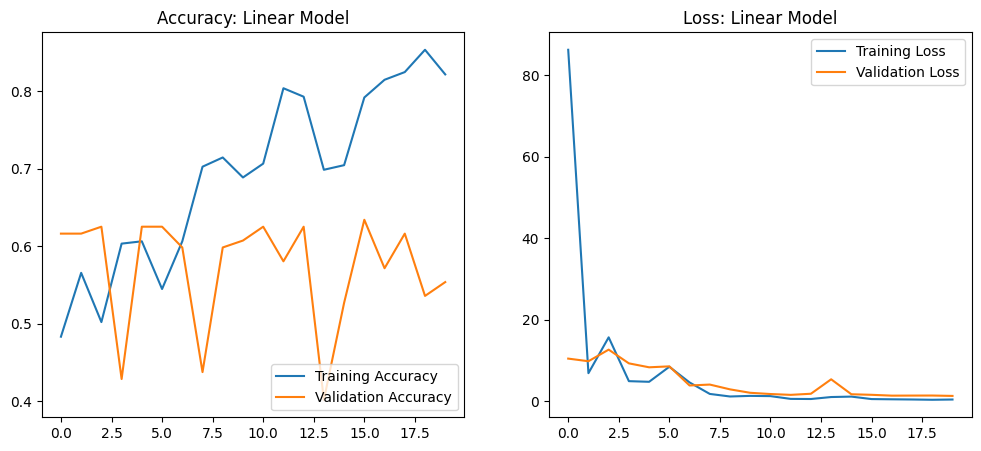

In [21]:
# Plot training curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy: Linear Model')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss: Linear Model')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


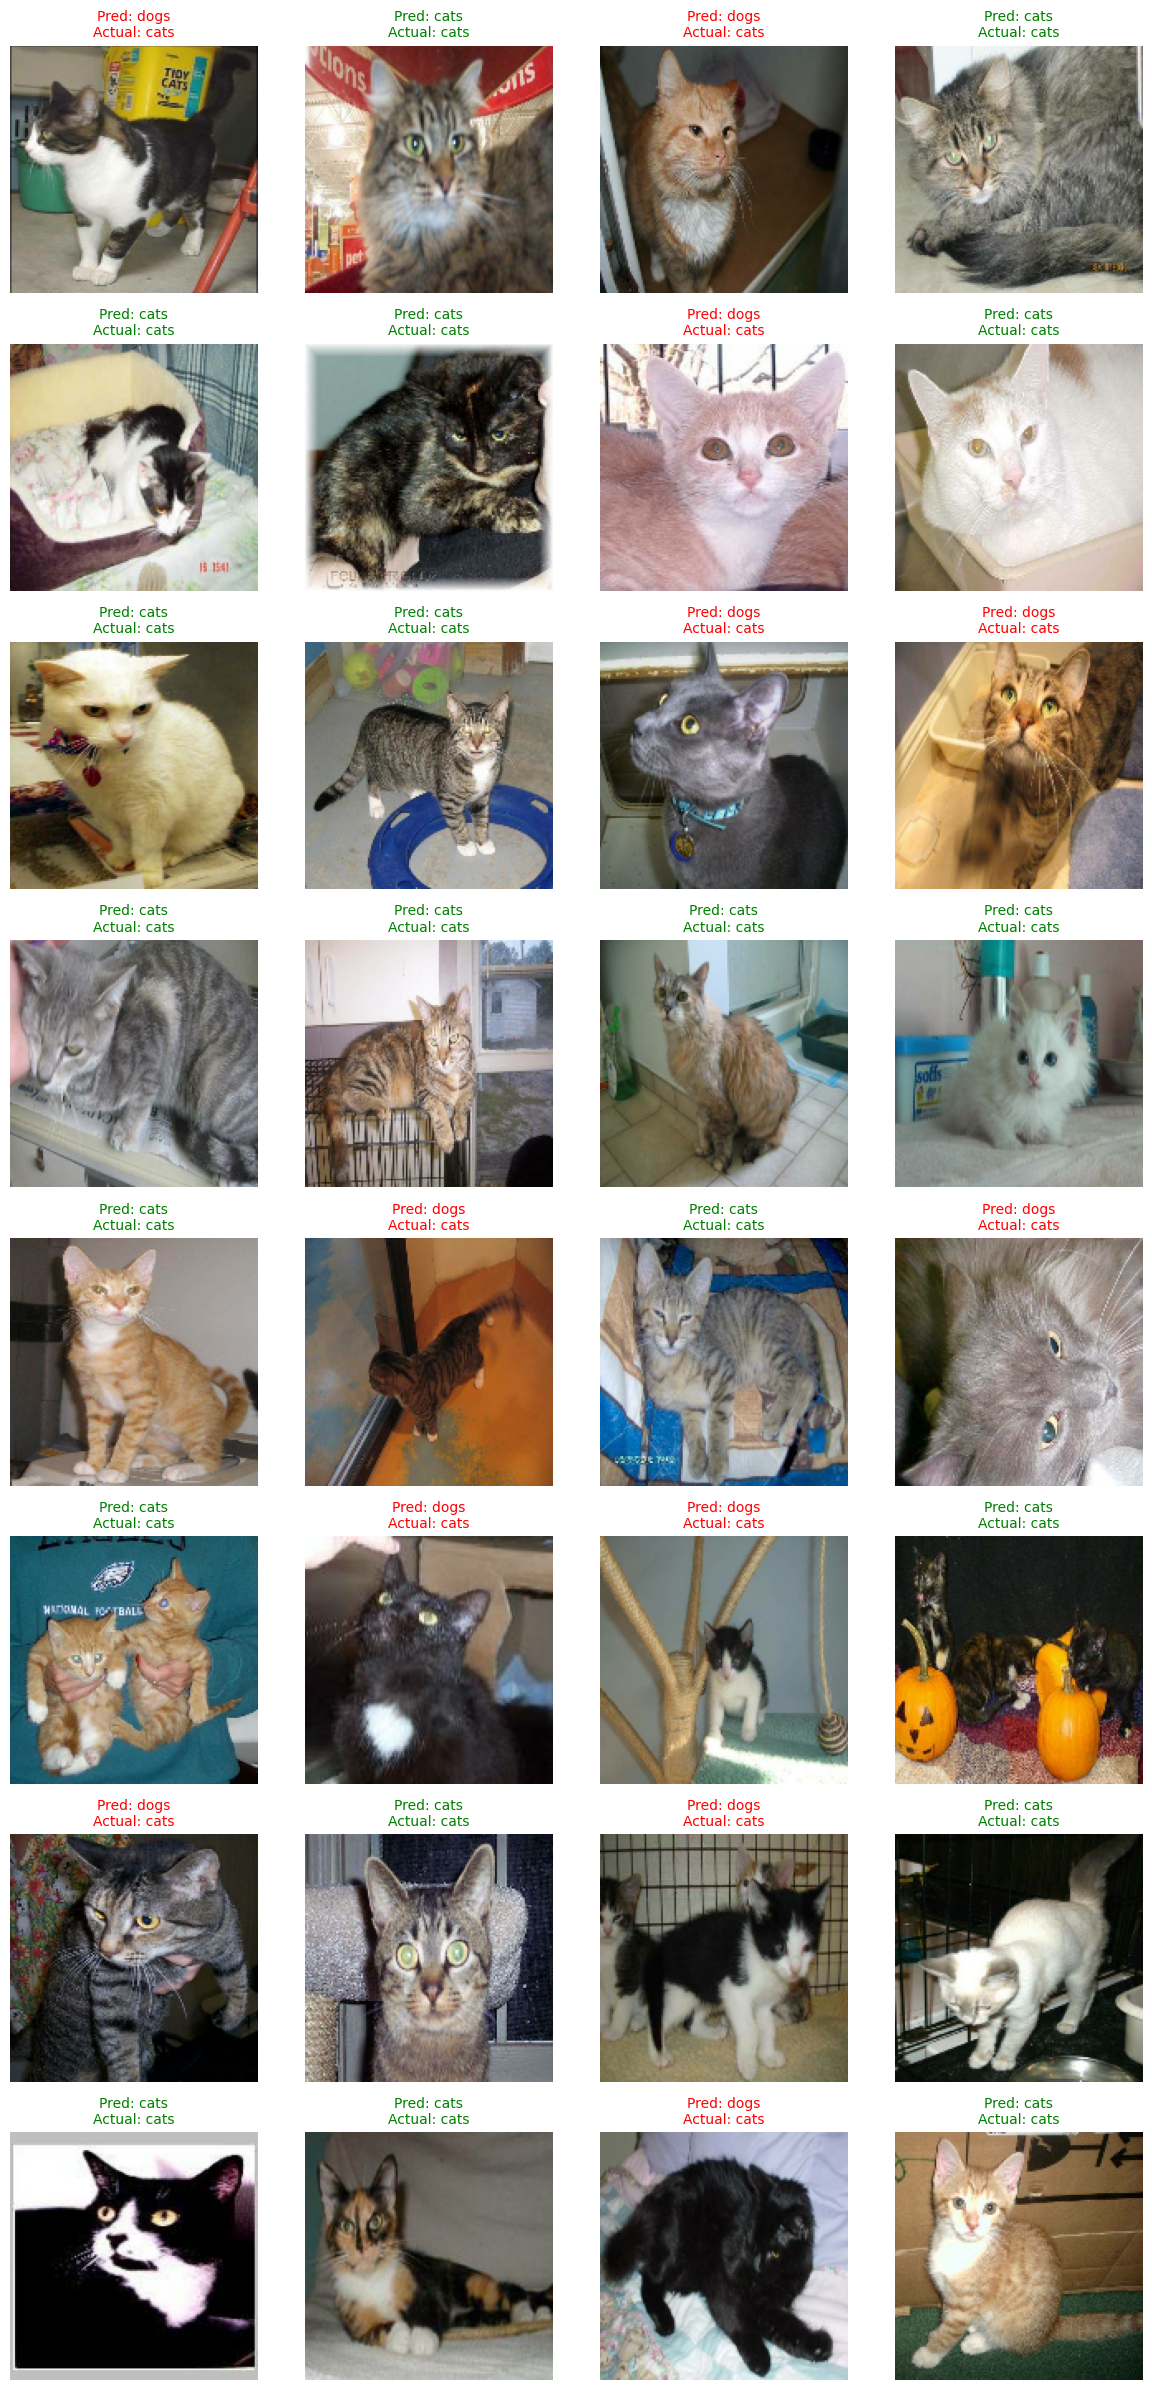

In [22]:
# Predictions vs actual labels on a test batch
for images, labels in test_ds.take(1):
  batch_predictions = linear_model.predict(images)
  predicted_indices = np.argmax(batch_predictions, axis=1)

  num_images = images.shape[0]
  num_cols = 4
  num_rows = math.ceil(num_images / num_cols)

  plt.figure(figsize=(12, 3 * num_rows))

  for i in range(num_images):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.axis('off')

    pred_class = CLASS_NAMES[predicted_indices[i]]
    actual_class = CLASS_NAMES[labels[i].numpy()]

    color = "green" if pred_class == actual_class else "red"
    plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10, color=color)

  plt.tight_layout()
  plt.show()